In [3]:
import xarray as xr 
import numpy as np 
import sys
import glob
import os
import xskillscore as xs
import pandas as pd
import random
import importlib

from scipy.stats import pearsonr

from datetime import datetime,timedelta


from concurrent.futures import ProcessPoolExecutor
import xarray as xr
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta

ROOT = "/home/563/fm6730/localrepo/wave_vertical_heating"

sys.path.insert(0, ROOT + "/src")

import func_python as fn
importlib.reload(fn)

<module 'func_python' from '/home/563/fm6730/localrepo/wave_vertical_heating/src/func_python.py'>

In [4]:
wave        = 'mjo'
season      = 'NDJFMA'
mode        = 'wet'
region_name = 'EIO-MC'

In [5]:
ctrl_lon,latN,latS,lonL,lonR = fn.get_region(region_name,wave)

In [6]:
var     = "rlut"
var2 = "olr"

if wave != 'tdsh' and wave != 'tdnh':
    file = f'local_{mode}_{wave}_phase_{season}_allclim.init_fors2s_{ctrl_lon}.nc'
    waveindex = wave
else:
    waveindex = wave
    file = f'local_{mode}_{waveindex}_phase_{season}_allclim.init_fors2s_{ctrl_lon}.nc'
    wave = 'td'
    
    print(f"{waveindex} change to {wave}")

home_raw=Path("/home/563/fm6730/localrepo/wave_vertical_heating/data/raw")
home_drv=Path("/home/563/fm6730/localrepo/wave_vertical_heating/data/derived")

folder_obs  = f'{home_raw}/observation/{var}'
# folder_s2s  = f'/scratch/v46/fm6730/dataout/access_s2/{var}/{wave}'
folder_s2s  = f'{home_drv}/access-s2_filtered/{var}/{wave}'
folder_init_phase = f'{home_drv}/local_wave_phase/'

# Load phase information
folder_phase = f'{home_drv}/local_wave_phase/'
# ensemble     = ['e01','e02','e03','ensmean_tlag']
ensemble     = ['e01','e02','e03']

In [7]:
folder_out = f"{home_drv}/acc/{var}/{wave}/{region_name}"
os.makedirs(folder_out, exist_ok=True)

#dictionary for each ensemble
wave_dict    = dict().fromkeys(ensemble, 0)

print(f"Central longitude: {ctrl_lon}\n")

Central longitude: 95



In [8]:
phase_file = os.path.join(folder_phase, file)

print(f"Loading phase data from: {phase_file}")
if not os.path.exists(phase_file):
    print(f"ERROR: Phase file not found: {phase_file}")
    sys.exit(1)

phases = xr.open_dataset(phase_file)

time_active = pd.to_datetime(phases.time.values)
time_active_str = set(time_active.strftime('%Y%m%d'))

init_sets = [init for init in time_active_str if init != '19810101']
init_sets = sorted(init_sets)  # Sort for consistent ordering

print(f"Processing {len(init_sets)} initializations...\n")

Loading phase data from: /home/563/fm6730/localrepo/wave_vertical_heating/data/derived/local_wave_phase/local_wet_mjo_phase_NDJFMA_allclim.init_fors2s_95.nc


Processing 74 initializations...



In [9]:
wave_dict = {}

with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {
        executor.submit(
            fn.process_ensemble_member, 
            e, 
            folder_s2s, 
            init_sets,
            wave, 
            var, 
            lonL, 
            lonR,
            latN,    # lat_N
            latS,    # lat_S
        ): e for e in ensemble if e != 'ensmean_tlag'
    }
    
    for future in futures:
        result = future.result()
        if result is not None:
            e, datasets_by_init = result
            
            # Concatenate all init dates into 'init' dimension
            ds_concat = xr.concat(datasets_by_init, dim='init')
            wave_dict[e] = ds_concat
            
            print(f"Processed {e}: shape = {ds_concat.sizes}")
            print(f"  init dates: {ds_concat.init.values}")
            print(f"  time_lag: {ds_concat.time_lag.values}")

Processed e01: shape = Frozen({'init': 74, 'time': 71, 'lat': 13, 'lon': 37, 'time_lag': 3})
  init dates: ['1981-02-01T00:00:00.000000000' '1981-11-01T00:00:00.000000000'
 '1981-12-01T00:00:00.000000000' '1982-01-01T00:00:00.000000000'
 '1982-11-01T00:00:00.000000000' '1982-12-01T00:00:00.000000000'
 '1983-01-01T00:00:00.000000000' '1984-12-01T00:00:00.000000000'
 '1986-11-01T00:00:00.000000000' '1987-01-01T00:00:00.000000000'
 '1987-11-01T00:00:00.000000000' '1988-02-01T00:00:00.000000000'
 '1988-03-01T00:00:00.000000000' '1988-12-01T00:00:00.000000000'
 '1989-03-01T00:00:00.000000000' '1989-04-01T00:00:00.000000000'
 '1990-01-01T00:00:00.000000000' '1990-03-01T00:00:00.000000000'
 '1990-11-01T00:00:00.000000000' '1991-04-01T00:00:00.000000000'
 '1991-12-01T00:00:00.000000000' '1992-04-01T00:00:00.000000000'
 '1993-04-01T00:00:00.000000000' '1993-12-01T00:00:00.000000000'
 '1994-12-01T00:00:00.000000000' '1995-04-01T00:00:00.000000000'
 '1995-11-01T00:00:00.000000000' '1996-02-01T00:

In [10]:
with ProcessPoolExecutor(max_workers=4) as executor:
    futures = {
        executor.submit(
            fn.process_truth,
            folder_obs, 
            folder_s2s, 
            init_sets,
            wave, 
            var, 
            lonL, 
            lonR,
            latN,    # lat_N
            latS,    # lat_S
        )
    }
    
    for future in futures:
        result = future.result()
        if result is not None:
            e, datasets_by_init = result
            
            # Concatenate all init dates into 'init' dimension
            ds_concat = xr.concat(datasets_by_init, dim='init')
            wave_dict[e] = ds_concat
            
            print(f"Processed {e}: shape = {ds_concat.sizes}")
            # print(f"  init dates: {ds_concat.init.values}")
            # print(f"  time_lag: {ds_concat.time_lag.values}")

Processed true: shape = Frozen({'init': 74, 'time': 72, 'lat': 13, 'lon': 37})


In [11]:
weights = np.cos(np.deg2rad(wave_dict['true'].lat))
weights.name = "weights"

tmp_ensmean = (wave_dict['e01'] + wave_dict['e02'] + wave_dict['e03'])/3.
wave_dict['ensmean'] = tmp_ensmean.mean(dim='time_lag')
del(tmp_ensmean)

for lag in wave_dict['e01']['time_lag']:
    print(lag)
    wave_dict[f'ensmean_tlag_{lag.values}'] = (wave_dict['e01'].sel(time_lag=lag) + wave_dict['e02'].sel(time_lag=lag) + wave_dict['e03'].sel(time_lag=lag))/3

acc_dict = {}
ensemble_ensmean = ['ensmean', 'ensmean_tlag_-2', 'ensmean_tlag_-1', 'ensmean_tlag_0']
ensemble_expand = ensemble + ensemble_ensmean
print(ensemble_expand)

for e in ensemble_expand:
    acc_dict[e] = fn.calculate_acc(wave_dict[e], wave_dict['true'], weights, latN=float(latN), latS=float(latS)) #OUTPUT IS R-correl

z_acc_dict = acc_dict.copy()
for keys in acc_dict.keys():
    z_acc_dict[keys] = np.arctanh(acc_dict[keys].copy()) #TO Z-transform



<xarray.DataArray 'time_lag' ()> Size: 4B
array(-2, dtype=int32)
Coordinates:
    time_lag  int32 4B -2
<xarray.DataArray 'time_lag' ()> Size: 4B
array(-1, dtype=int32)
Coordinates:
    time_lag  int32 4B -1
<xarray.DataArray 'time_lag' ()> Size: 4B
array(0, dtype=int32)
Coordinates:
    time_lag  int32 4B 0
['e01', 'e02', 'e03', 'ensmean', 'ensmean_tlag_-2', 'ensmean_tlag_-1', 'ensmean_tlag_0']


In [12]:
acc_dict

{'e01': <xarray.Dataset> Size: 127kB
 Dimensions:   (time_lag: 3, time: 71, init: 74)
 Coordinates:
   * time_lag  (time_lag) int32 12B -2 -1 0
   * time      (time) int64 568B -1 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68 69
   * init      (init) datetime64[ns] 592B 1981-02-01 1981-11-01 ... 2018-01-01
 Data variables:
     mjo       (init, time, time_lag) float64 126kB 0.6344 0.7184 ... 0.0838
 Attributes:
     axis:           Y
     units:          degrees_north
     long_name:      Latitude
     standard_name:  latitude,
 'e02': <xarray.Dataset> Size: 127kB
 Dimensions:   (time_lag: 3, time: 71, init: 74)
 Coordinates:
   * time_lag  (time_lag) int32 12B -2 -1 0
   * time      (time) int64 568B -1 0 1 2 3 4 5 6 7 ... 62 63 64 65 66 67 68 69
   * init      (init) datetime64[ns] 592B 1981-02-01 1981-11-01 ... 2018-01-01
 Data variables:
     mjo       (init, time, time_lag) float64 126kB 0.7377 0.6781 ... 0.03686
 Attributes:
     axis:           Y
     units:          degrees_north
  

In [13]:
check = acc_dict['ensmean']

In [15]:
masked = check < 0.5
first_idx = masked.argmax(dim="time")



In [36]:
q1 = first_idx.mjo.quantile(0.33)
q2 = first_idx.mjo.quantile(0.66)
qm = first_idx.mjo.quantile(0.50)


In [37]:
qm

<xarray.DataArray 'mjo' ()> Size: 8B
array(13.)
Coordinates:
    quantile  float64 8B 0.5
Attributes:
    axis:           Y
    standard_name:  latitude
    long_name:      Madden-Julian Oscillations in Outgoing Longwave Radiation
    units:          W/m^2

In [56]:
# category = xr.where(first_idx.mjo <= q1, "worst",
#             xr.where(first_idx.mjo <= q2, "moderate", "best"))

category = xr.where(first_idx.mjo < 21, "bad",
            xr.where(first_idx.mjo >=21, "good",""))

In [57]:
category

<xarray.DataArray 'mjo' (init: 74)> Size: 1kB
array(['bad', 'bad', 'good', 'good', 'good', 'bad', 'bad', 'bad', 'good',
       'bad', 'good', 'bad', 'bad', 'bad', 'good', 'bad', 'bad', 'good',
       'bad', 'bad', 'bad', 'good', 'good', 'bad', 'good', 'good', 'bad',
       'bad', 'good', 'good', 'good', 'good', 'bad', 'bad', 'bad', 'bad',
       'bad', 'bad', 'bad', 'good', 'bad', 'bad', 'bad', 'bad', 'bad',
       'good', 'good', 'bad', 'bad', 'good', 'bad', 'good', 'bad', 'bad',
       'bad', 'bad', 'bad', 'bad', 'good', 'good', 'bad', 'good', 'bad',
       'bad', 'bad', 'bad', 'bad', 'bad', 'bad', 'bad', 'bad', 'bad',
       'bad', 'good'], dtype='<U4')
Coordinates:
  * init     (init) datetime64[ns] 592B 1981-02-01 1981-11-01 ... 2018-01-01

In [58]:
best_dates = check.init.where(category == "best", drop=True)
worst_dates = check.init.where(category == "worst", drop=True)
moderate_dates = check.init.where(category == "moderate", drop=True)

In [59]:
good_dates = check.init.where(category == "good", drop=True)
bad_dates = check.init.where(category == "bad", drop=True)

In [67]:
bad_dates

<xarray.DataArray 'init' (init: 50)> Size: 400B
array(['1981-02-01T00:00:00.000000000', '1981-11-01T00:00:00.000000000',
       '1982-12-01T00:00:00.000000000', '1983-01-01T00:00:00.000000000',
       '1984-12-01T00:00:00.000000000', '1987-01-01T00:00:00.000000000',
       '1988-02-01T00:00:00.000000000', '1988-03-01T00:00:00.000000000',
       '1988-12-01T00:00:00.000000000', '1989-04-01T00:00:00.000000000',
       '1990-01-01T00:00:00.000000000', '1990-11-01T00:00:00.000000000',
       '1991-04-01T00:00:00.000000000', '1991-12-01T00:00:00.000000000',
       '1993-12-01T00:00:00.000000000', '1995-11-01T00:00:00.000000000',
       '1996-02-01T00:00:00.000000000', '1997-04-01T00:00:00.000000000',
       '1998-11-01T00:00:00.000000000', '1999-12-01T00:00:00.000000000',
       '2000-01-01T00:00:00.000000000', '2000-04-01T00:00:00.000000000',
       '2001-02-01T00:00:00.000000000', '2001-11-01T00:00:00.000000000',
       '2002-04-01T00:00:00.000000000', '2003-02-01T00:00:00.000000000',
       '2004-02-01T00:00:00.000000000', '2004-03-01T00:00:00.000000000',
       '2004-11-01T00:00:00.000000000', '2006-03-01T00:00:00.000000000',
       '2007-01-01T00:00:00.000000000', '2007-11-01T00:00:00.000000000',
       '2009-02-01T00:00:00.000000000', '2009-03-01T00:00:00.000000000',
       '2010-01-01T00:00:00.000000000', '2010-04-01T00:00:00.000000000',
       '2010-12-01T00:00:00.000000000', '2011-01-01T00:00:00.000000000',
       '2012-03-01T00:00:00.000000000', '2013-01-01T00:00:00.000000000',
       '2013-04-01T00:00:00.000000000', '2014-04-01T00:00:00.000000000',
       '2014-12-01T00:00:00.000000000', '2015-02-01T00:00:00.000000000',
       '2015-04-01T00:00:00.000000000', '2015-12-01T00:00:00.000000000',
       '2016-04-01T00:00:00.000000000', '2016-12-01T00:00:00.000000000',
       '2017-03-01T00:00:00.000000000', '2017-12-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * init     (init) datetime64[ns] 400B 1981-02-01 1981-11-01 ... 2017-12-01

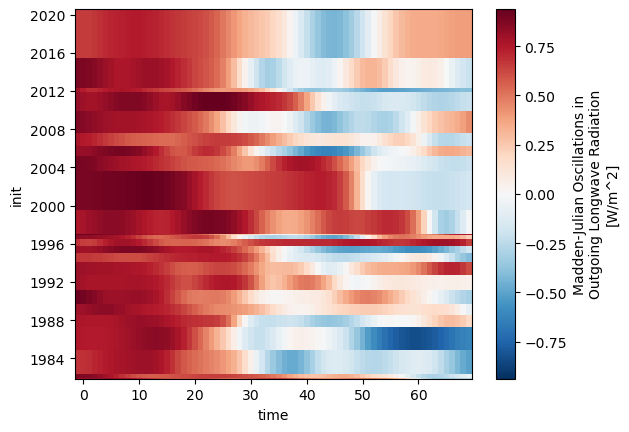

In [65]:
check_good = check.sel(init=good_dates)
check_good.mjo.plot()


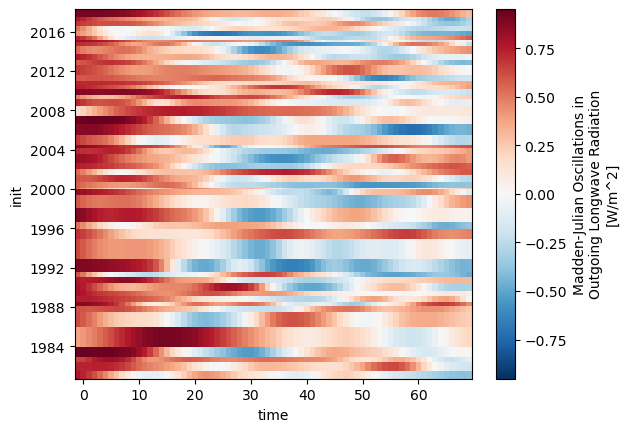

In [66]:

check_bad = check.sel(init=bad_dates)
check_bad.mjo.plot()